In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score

In [236]:

df = pd.read_csv(
    r"C:\Users\ratho\Desktop\COSC-5806-W03---Data-Analysis-With-Python\VestasV52_10_min_raw_SCADA_DkIT 30_Jan2006-12_Mar2020.csv",
    low_memory=True
)

# view first rows
df.head()


,Timestamps,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,...,RotorRPM,EnvirTemp,NacelTemp,GearOilTemp,GearBearTemp,GenTemp,GenPh1Temp,GenPh2Temp,GenPh3Temp,GenBearTemp
0,2006-01-30 20:30,9.5,0.7,101.9,2.0,527.3,633.2,362.3,48.8,0.0,...,26.1,5,18,55,63,999,82,82,81,62
1,2006-01-30 20:40,9.9,0.9,107.1,2.5,584.5,731.5,353.3,74.6,0.0,...,26.1,5,18,57,65,999,86,85,85,64
2,2006-01-30 20:50,9.3,0.9,105.0,-0.5,527.3,728.1,291.1,92.7,0.0,...,25.9,4,17,57,65,999,89,88,88,64
3,2006-01-30 21:00,8.7,0.8,106.3,0.8,428.0,669.4,216.7,92.9,0.0,...,25.5,4,15,55,63,999,88,88,88,60
4,2006-01-30 21:10,8.6,0.8,103.5,-2.0,434.7,622.2,233.1,80.3,0.0,...,25.4,4,15,57,66,999,85,85,84,57


In [237]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (653103, 22)

Columns:
 Index(['Timestamps', 'WindSpeed', 'StdDevWindSpeed', 'WindDirAbs',
       'WindDirRel', 'Power', 'MaxPower', 'MinPower', 'StdDevPower', 'AvgRPow',
       'Pitch', 'GenRPM', 'RotorRPM', 'EnvirTemp', 'NacelTemp', 'GearOilTemp',
       'GearBearTemp', 'GenTemp', 'GenPh1Temp', 'GenPh2Temp', 'GenPh3Temp',
       'GenBearTemp'],
      dtype='object')


In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653103 entries, 0 to 653102
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamps       653103 non-null  object 
 1   WindSpeed        653103 non-null  float64
 2   StdDevWindSpeed  653103 non-null  float64
 3   WindDirAbs       653103 non-null  float64
 4   WindDirRel       653103 non-null  float64
 5   Power            653103 non-null  float64
 6   MaxPower         653103 non-null  float64
 7   MinPower         653103 non-null  float64
 8   StdDevPower      653103 non-null  float64
 9   AvgRPow          653103 non-null  float64
 10  Pitch            653103 non-null  float64
 11  GenRPM           653103 non-null  int64  
 12  RotorRPM         653103 non-null  float64
 13  EnvirTemp        653103 non-null  int64  
 14  NacelTemp        653103 non-null  int64  
 15  GearOilTemp      653103 non-null  int64  
 16  GearBearTemp     653103 non-null  int6

In [239]:
df.isnull().sum()

Timestamps         0
WindSpeed          0
StdDevWindSpeed    0
WindDirAbs         0
WindDirRel         0
Power              0
MaxPower           0
MinPower           0
StdDevPower        0
AvgRPow            0
Pitch              0
GenRPM             0
RotorRPM           0
EnvirTemp          0
NacelTemp          0
GearOilTemp        0
GearBearTemp       0
GenTemp            0
GenPh1Temp         0
GenPh2Temp         0
GenPh3Temp         0
GenBearTemp        0
dtype: int64

In [240]:
(df == 999).sum()

Timestamps              0
WindSpeed               0
StdDevWindSpeed         0
WindDirAbs              0
WindDirRel              0
Power                   0
MaxPower                0
MinPower                0
StdDevPower             0
AvgRPow                 0
Pitch                   0
GenRPM               7767
RotorRPM                0
EnvirTemp               0
NacelTemp               0
GearOilTemp             0
GearBearTemp            0
GenTemp            653103
GenPh1Temp              0
GenPh2Temp              0
GenPh3Temp              0
GenBearTemp             0
dtype: int64

4.

In [241]:
df["Timestamps"] = pd.to_datetime(df["Timestamps"], format="mixed", errors="coerce")

In [242]:
df.replace(999, np.nan, inplace=True)

In [243]:
empty_cols = [col for col in df.columns if df[col].isna().all()]
print("Empty columns:", empty_cols)

df.drop(columns=empty_cols, inplace=True)

Empty columns: ['GenTemp']


In [244]:
df = df.dropna(subset=["WindSpeed", "Power", "RotorRPM"])

In [245]:
df = df[(df["Power"] > 0) & (df["WindSpeed"] > 0)]
df = df[df["WindSpeed"] < 30]

In [246]:
df = df.sort_values("Timestamps")
df.set_index("Timestamps", inplace=True)

In [247]:
df.interpolate(inplace=True)

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456813 entries, 2006-01-30 20:30:00 to 2020-03-12 12:20:00
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   WindSpeed        456813 non-null  float64
 1   StdDevWindSpeed  456813 non-null  float64
 2   WindDirAbs       456813 non-null  float64
 3   WindDirRel       456813 non-null  float64
 4   Power            456813 non-null  float64
 5   MaxPower         456813 non-null  float64
 6   MinPower         456813 non-null  float64
 7   StdDevPower      456813 non-null  float64
 8   AvgRPow          456813 non-null  float64
 9   Pitch            456813 non-null  float64
 10  GenRPM           456813 non-null  float64
 11  RotorRPM         456813 non-null  float64
 12  EnvirTemp        456813 non-null  int64  
 13  NacelTemp        456813 non-null  int64  
 14  GearOilTemp      456813 non-null  int64  
 15  GearBearTemp     456813 non-null  int64  
 16  GenP

In [249]:
df.head()

,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,Pitch,GenRPM,RotorRPM,EnvirTemp,NacelTemp,GearOilTemp,GearBearTemp,GenPh1Temp,GenPh2Temp,GenPh3Temp,GenBearTemp
Timestamps,,,,,,,,,,,,,,,,,,,,
2006-01-30 20:30:00,9.5,0.7,101.9,2.0,527.3,633.2,362.3,48.8,0.0,-1.2,1618.0,26.1,5,18,55,63,82,82,81,62
2006-01-30 20:40:00,9.9,0.9,107.1,2.5,584.5,731.5,353.3,74.6,0.0,-0.8,1618.0,26.1,5,18,57,65,86,85,85,64
2006-01-30 20:50:00,9.3,0.9,105.0,-0.5,527.3,728.1,291.1,92.7,0.0,-1.2,1604.0,25.9,4,17,57,65,89,88,88,64
2006-01-30 21:00:00,8.7,0.8,106.3,0.8,428.0,669.4,216.7,92.9,0.0,-1.7,1583.0,25.5,4,15,55,63,88,88,88,60
2006-01-30 21:10:00,8.6,0.8,103.5,-2.0,434.7,622.2,233.1,80.3,0.0,-1.7,1577.0,25.4,4,15,57,66,85,85,84,57


eda

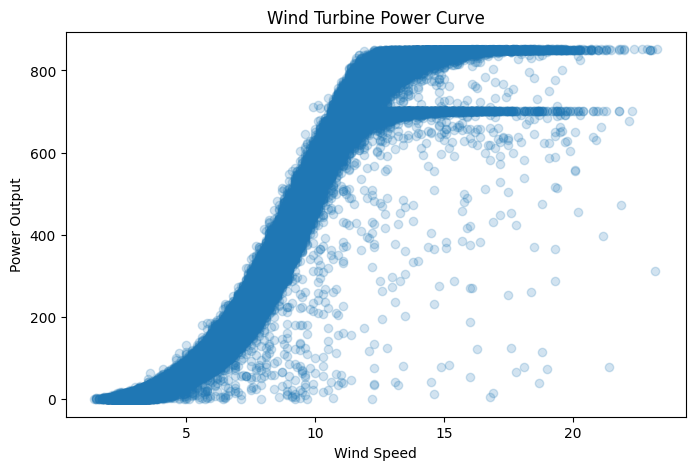

In [250]:
plt.figure(figsize=(8, 5))
plt.scatter(df["WindSpeed"], df["Power"], alpha=0.2)
plt.xlabel("Wind Speed")
plt.ylabel("Power Output")
plt.title("Wind Turbine Power Curve")
plt.show()

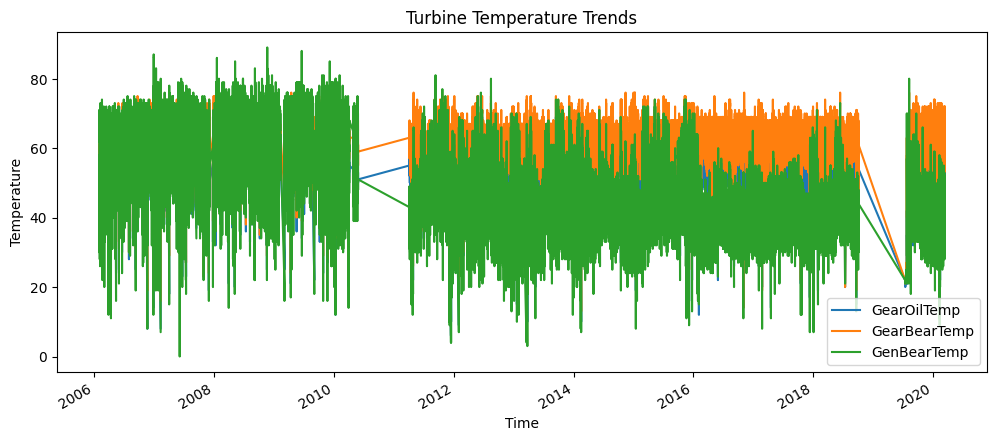

In [251]:
df[["GearOilTemp", "GearBearTemp", "GenBearTemp"]].plot(figsize=(12, 5))
plt.title("Turbine Temperature Trends")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

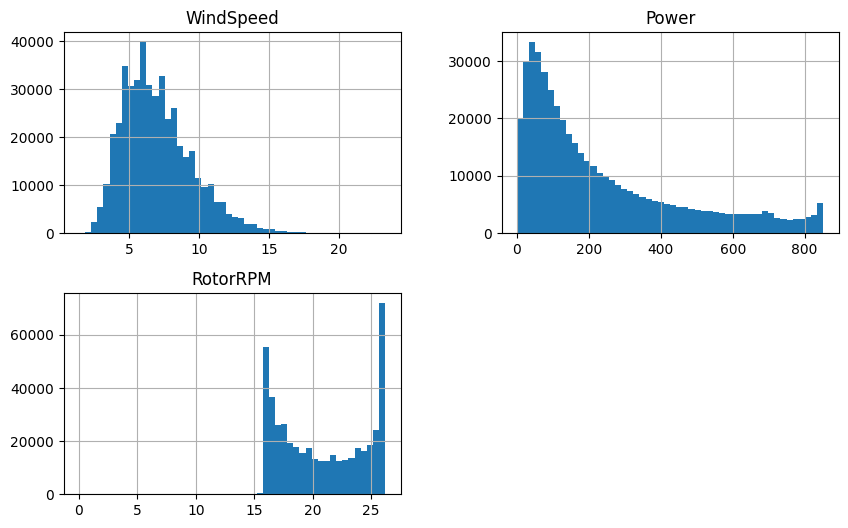

In [252]:
df[["WindSpeed", "Power", "RotorRPM"]].hist(figsize=(10, 6), bins=50)
plt.show()

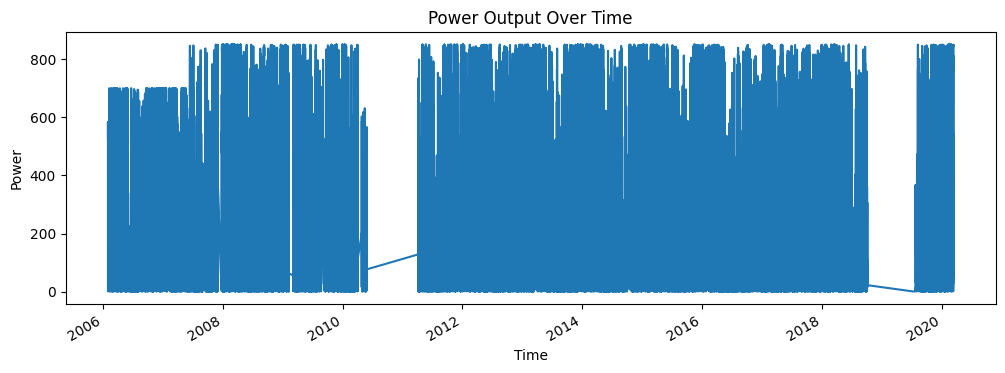

In [253]:
df["Power"].plot(figsize=(12, 4))
plt.title("Power Output Over Time")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

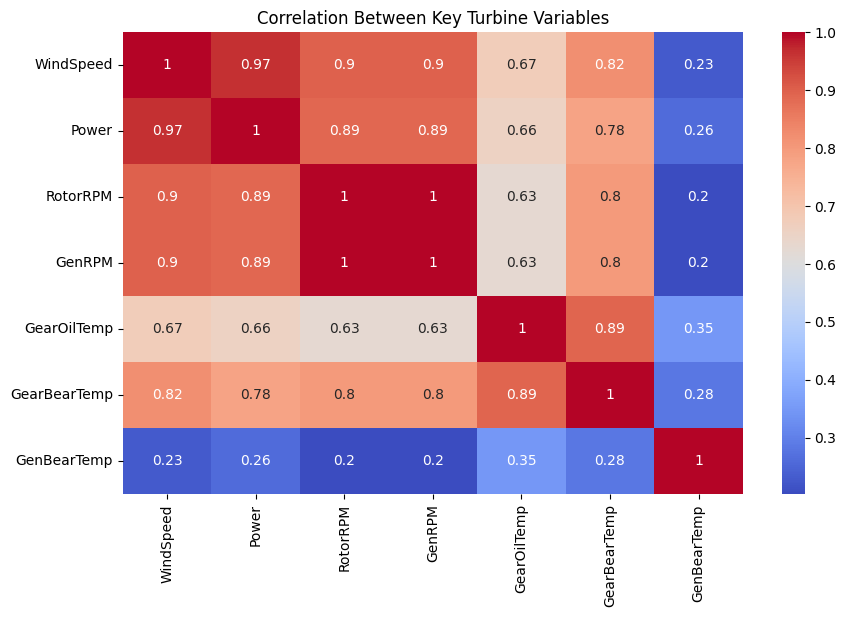

In [254]:
cols = [
    "WindSpeed", "Power", "RotorRPM", "GenRPM",
    "GearOilTemp", "GearBearTemp", "GenBearTemp"
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[cols].corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Between Key Turbine Variables")
plt.show()

In [255]:
X = df[["WindSpeed"]]
y = df["Power"]

In [256]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

In [257]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [258]:
df["PredictedPower"] = model.predict(X_poly)

In [259]:
df["Residual"] = df["Power"] - df["PredictedPower"]

c:\Users\ratho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


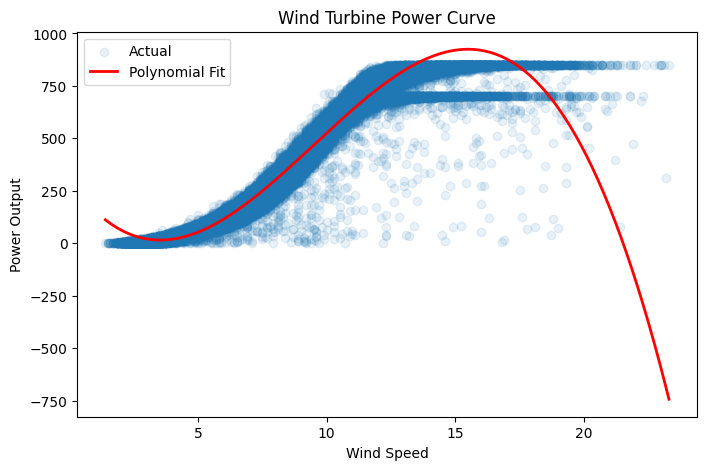

In [260]:
ws = np.linspace(df["WindSpeed"].min(), df["WindSpeed"].max(), 200).reshape(-1, 1)
ws_poly = poly.transform(ws)
pred_curve = model.predict(ws_poly)

plt.figure(figsize=(8, 5))
plt.scatter(df["WindSpeed"], df["Power"], alpha=0.1, label="Actual")
plt.plot(ws, pred_curve, color="red", linewidth=2, label="Polynomial Fit")
plt.xlabel("Wind Speed")
plt.ylabel("Power Output")
plt.title("Wind Turbine Power Curve")
plt.legend()
plt.show()

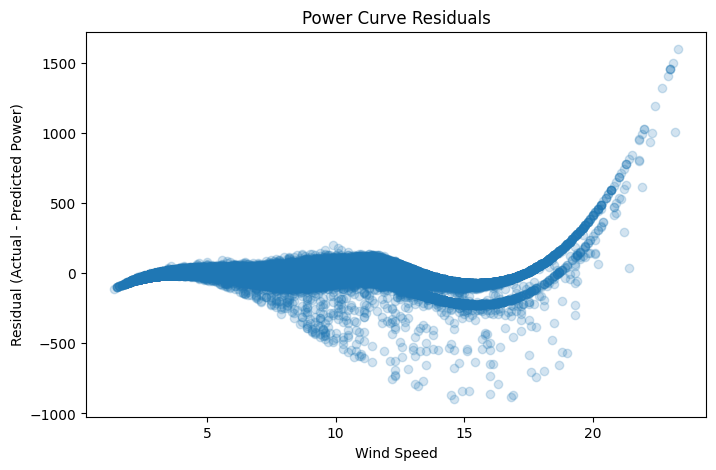

In [261]:
plt.figure(figsize=(8, 5))
plt.scatter(df["WindSpeed"], df["Residual"], alpha=0.2)
plt.xlabel("Wind Speed")
plt.ylabel("Residual (Actual - Predicted Power)")
plt.title("Power Curve Residuals")
plt.show()

In [262]:
rmse = np.sqrt(mean_squared_error(y, df["PredictedPower"]))
r2 = r2_score(y, df["PredictedPower"])

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 30.77299087104973
R2 Score: 0.9804485082694105


In [263]:
df["GearTempDiff"] = df["GearOilTemp"] - df["EnvirTemp"]
df["BearTempDiff"] = df["GearBearTemp"] - df["EnvirTemp"]
df["GenBearTempDiff"] = df["GenBearTemp"] - df["EnvirTemp"]

In [264]:
df["PowerRollingMean"] = df["Power"].rolling(12).mean()
df["PowerRollingStd"] = df["Power"].rolling(12).std()

In [265]:
df.dropna(inplace=True)

In [266]:
df[[
    "GearTempDiff", "BearTempDiff", "GenBearTempDiff",
    "PowerRollingMean", "PowerRollingStd"
]].head()

,GearTempDiff,BearTempDiff,GenBearTempDiff,PowerRollingMean,PowerRollingStd
Timestamps,,,,,
2006-01-30 22:20:00,50,58,54,393.033333,120.347552
2006-01-30 22:30:00,53,60,56,366.116667,123.662854
2006-01-30 22:40:00,52,60,57,341.750000,103.957985
2006-01-30 22:50:00,50,58,59,318.391667,88.872385
2006-01-30 23:00:00,53,61,60,305.950000,82.343631


In [267]:
health_features = [
    "Power",
    "RotorRPM",
    "GearOilTemp",
    "GearBearTemp",
    "GenBearTemp",
    "GearTempDiff",
    "BearTempDiff",
    "GenBearTempDiff",
    "PowerRollingMean",
    "PowerRollingStd",
    "Residual"
]

In [268]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[health_features])

In [269]:
pca = PCA(n_components=1)
df["HealthIndex"] = pca.fit_transform(X_scaled)

In [270]:
df["HealthIndexSmooth"] = df["HealthIndex"].rolling(12).mean()

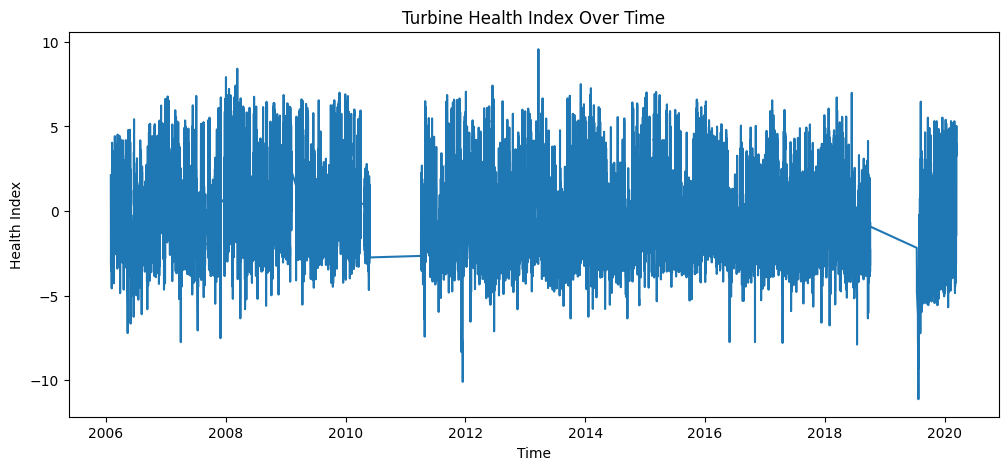

In [271]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["HealthIndexSmooth"])
plt.title("Turbine Health Index Over Time")
plt.xlabel("Time")
plt.ylabel("Health Index")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# define features
anomaly_features = [
    "Residual",
    "GearTempDiff",
    "BearTempDiff",
    "GenBearTempDiff",
    "PowerRollingStd",
    "HealthIndex"
]

# drop missing
df = df.dropna(subset=anomaly_features)

# SCALE DATA  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[anomaly_features])

# train model with higher contamination
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # increased
    random_state=42
)

df["Anomaly"] = iso.fit_predict(X_scaled)

# convert output
df["Anomaly"] = df["Anomaly"].map({1: 0, -1: 1})

# check
print("Anomaly %:", df["Anomaly"].mean() * 100)

Anomaly %: 5.000197021904458


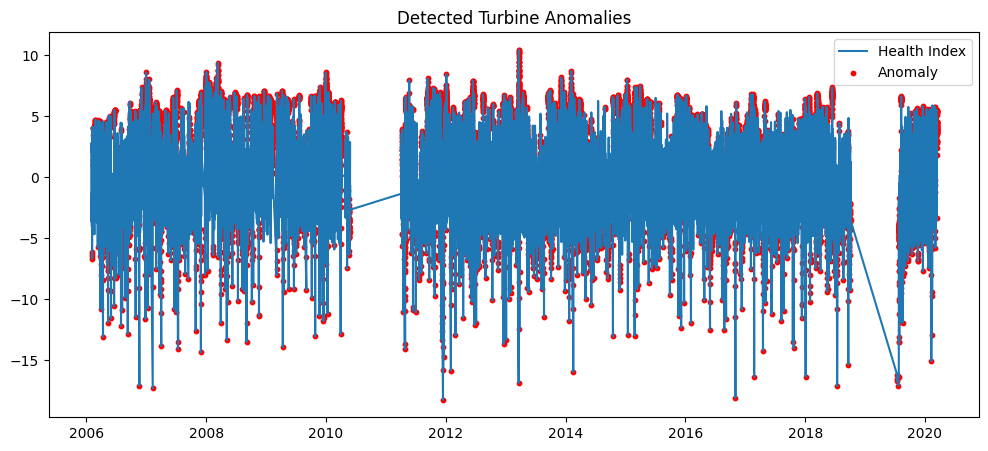

In [273]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["HealthIndex"], label="Health Index")

anomalies = df[df["Anomaly"] == 1]

plt.scatter(
    anomalies.index,
    anomalies["HealthIndex"],
    color="red",
    s=10,
    label="Anomaly"
)

plt.title("Detected Turbine Anomalies")
plt.legend()
plt.show()

# 10. setting early warning count

In [274]:
df["AnomalyRolling"] = df["Anomaly"].rolling(12).sum()

In [275]:
df["EarlyWarning"] = df["AnomalyRolling"] >= 9

# warning count

In [276]:
print("Total Early Warning Events:", df["EarlyWarning"].sum())

Total Early Warning Events: 12110


# Early warning plot

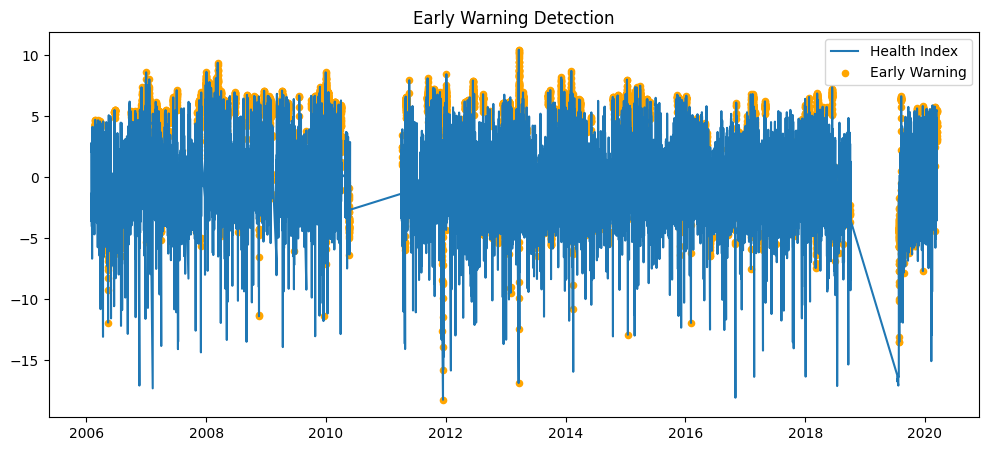

In [277]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["HealthIndex"], label="Health Index")

warnings = df[df["EarlyWarning"] == True]

plt.scatter(
    warnings.index,
    warnings["HealthIndex"],
    color="orange",
    s=20,
    label="Early Warning"
)

plt.title("Early Warning Detection")
plt.legend()
plt.show()

# 11. FINAL OUTPUT 

# Anomly rows

In [278]:
df[df["Anomaly"] == 1].head(20)

,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,Pitch,...,GearTempDiff,BearTempDiff,GenBearTempDiff,PowerRollingMean,PowerRollingStd,HealthIndex,HealthIndexSmooth,Anomaly,AnomalyRolling,EarlyWarning
Timestamps,,,,,,,,,,,,,,,,,,,,,
2006-02-05 04:50:00,3.1,0.6,238.7,3.9,5.0,104.0,-5.8,18.7,0.6,2.2,...,29,41,19,26.916667,17.473036,-6.675409,-3.031927,1,1.0,False
2006-02-05 05:00:00,4.1,0.4,237.7,1.2,34.1,50.7,14.8,8.4,0.0,-0.5,...,31,43,21,25.483333,15.928182,-6.462191,-3.363250,1,2.0,False
2006-02-05 05:10:00,4.5,0.3,241.1,4.6,46.4,73.0,26.9,9.0,0.0,-0.8,...,32,43,21,25.100000,15.301277,-6.288898,-3.694274,1,3.0,False
2006-02-05 05:40:00,2.5,0.7,225.4,-0.8,4.3,23.7,-5.6,7.1,3.1,0.6,...,34,43,23,21.133333,14.731681,-6.106995,-4.558829,1,4.0,False
2006-02-07 17:30:00,12.8,1.6,253.7,1.6,697.2,745.8,506.3,22.6,0.0,6.0,...,52,59,51,695.375000,6.032507,4.026565,3.748214,1,1.0,False
2006-02-07 17:40:00,12.9,1.8,256.3,4.2,692.0,747.5,463.7,35.3,0.0,5.8,...,52,59,51,694.683333,5.890645,3.994054,3.842044,1,2.0,False
2006-02-08 23:50:00,9.2,0.6,318.9,-1.5,497.9,581.4,405.1,30.6,0.0,-1.5,...,55,62,61,279.716667,130.869983,4.015245,1.917151,1,1.0,False
2006-02-09 00:00:00,8.8,0.7,318.7,-1.7,449.4,570.8,262.9,65.3,0.0,-1.7,...,55,62,62,297.858333,138.476736,3.999679,2.143722,1,2.0,False
2006-02-09 01:10:00,3.7,0.6,309.4,2.2,26.6,55.1,3.6,14.1,0.0,-0.1,...,53,58,68,280.900000,168.201978,1.377916,2.559738,1,3.0,False


# Early warning Rows

In [279]:
df[df["EarlyWarning"] == True].head(20)

,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,Pitch,...,GearTempDiff,BearTempDiff,GenBearTempDiff,PowerRollingMean,PowerRollingStd,HealthIndex,HealthIndexSmooth,Anomaly,AnomalyRolling,EarlyWarning
Timestamps,,,,,,,,,,,,,,,,,,,,,
2006-02-24 12:30:00,14.4,2.7,82.3,-2.2,700.9,724.4,671.4,8.3,0.0,10.5,...,55,62,50,622.058333,137.818170,4.662731,3.635327,1,9.0,True
2006-02-24 12:40:00,14.3,2.8,77.6,-1.6,700.8,744.7,661.8,8.4,0.0,9.6,...,55,62,50,632.541667,138.694986,4.692095,3.772514,1,10.0,True
2006-02-24 12:50:00,15.7,2.3,79.0,1.4,700.9,737.0,670.4,8.9,0.0,12.7,...,55,62,51,662.850000,103.582339,4.563435,3.994352,1,11.0,True
2006-02-24 13:00:00,15.0,2.7,79.6,2.0,699.6,736.3,579.5,13.4,0.0,11.0,...,55,62,51,692.275000,28.453443,4.247025,4.170206,1,12.0,True
2006-02-24 13:10:00,13.2,2.4,72.6,-1.4,694.0,757.5,520.9,29.1,0.0,7.3,...,55,62,51,699.941667,2.208438,4.250718,4.245442,1,12.0,True
2006-02-24 13:20:00,14.8,2.3,77.1,1.0,700.8,725.4,670.4,7.7,0.0,10.5,...,55,62,52,699.916667,2.195795,4.173191,4.284566,1,12.0,True
2006-02-24 13:30:00,15.1,2.3,79.3,1.2,700.7,729.3,670.9,7.1,0.0,10.9,...,56,63,53,699.900000,2.188399,4.292412,4.336417,1,12.0,True
2006-02-24 13:40:00,13.5,2.4,82.3,2.7,696.3,746.7,536.8,21.9,0.0,7.8,...,56,63,53,699.841667,2.280135,4.385476,4.385547,1,12.0,True
2006-02-24 13:50:00,11.9,1.8,83.0,-1.0,684.4,736.7,472.0,47.2,0.0,4.6,...,55,63,53,698.458333,4.966517,4.418329,4.422745,1,12.0,True


In [280]:
df.to_csv("turbine_analysis_results.csv")

In [281]:
print("Final Dataset Shape:", df.shape)
print("Sampling Interval: 10 minutes")
print("Anomaly Rate (%):", round(df["Anomaly"].mean() * 100, 2))
print("Total Early Warning Events:", int(df["EarlyWarning"].sum()))

Final Dataset Shape: (456802, 32)
Sampling Interval: 10 minutes
Anomaly Rate (%): 5.0
Total Early Warning Events: 12110


# Model training - testing

In [282]:

from sklearn.model_selection import train_test_split

# features and target
X = df[["WindSpeed"]]
y = df["Power"]

# polynomial transform
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# train
model = LinearRegression()
model.fit(X_train, y_train)

# test predictions
y_pred = model.predict(X_test)

# evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

df["PredictedPower"] = model.predict(X_poly)
df["Residual"] = df["Power"] - df["PredictedPower"]

RMSE: 31.116200884838598
R2 Score: 0.9799936106774969


# evaluation plot

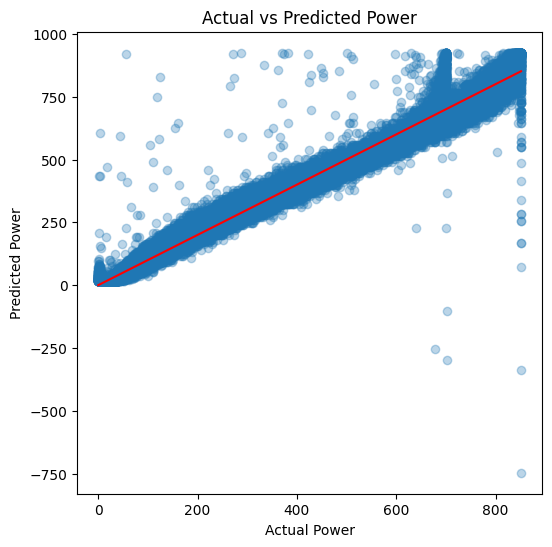

In [283]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

# Residual distribution

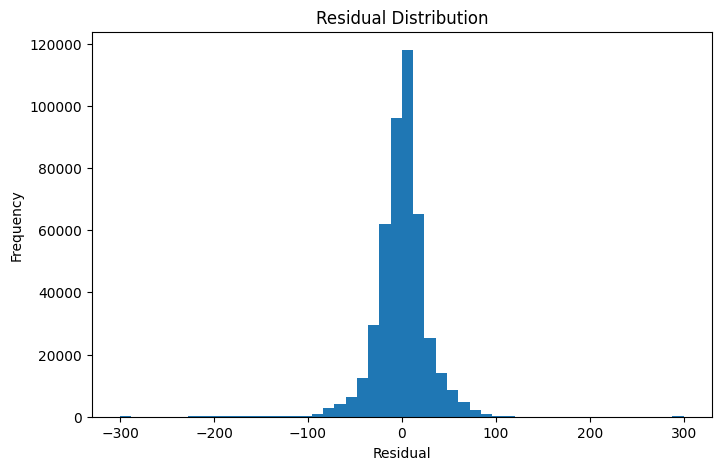

In [284]:
df["Residual"] = df["Residual"].clip(-300, 300)

plt.figure(figsize=(8,5))
plt.hist(df["Residual"], bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# Save the model

In [285]:
import joblib
joblib.dump(model, "power_model.pkl")
joblib.dump(poly, "poly_transform.pkl")

['poly_transform.pkl']